# Carousel Lens — Source 4 (S4) Single-Source MAP

Models only S4 (z_s=1.432, Einstein cross) in HST WFC3/IR F140W.  
Mass : La (EPL) + Ld (DPIE) + external shear  
Foreground : BCG SersicEllipse (lstsq)  
Source : SersicShapelets(n_max=8, lstsq), deflection_ratio=0.5619  
Mask : arc-position apertures around S4's four image centroids + BCG  

Reference: Urcelay et al. 2026 (arXiv:2602.16077)

## 1. Imports

In [ ]:
import sys
sys.path.insert(0, '../sean-carousel/src')

import numpy as np
import optax
import jax
import jax.numpy as jnp
from astropy.io import fits
from astropy.visualization import simple_norm
from matplotlib import pyplot as plt
from matplotlib.patches import Circle
import tensorflow_probability.substrates.jax as tfp

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import BackwardProbModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles import mass, light
from gigalens.jax.profiles.light import sersic_shapelets as ss_mod
from gigalens.jax.prior import Prior, make_prior_and_model

tfd = tfp.distributions
plt.rcParams['figure.dpi'] = 150
print('Imports OK | devices:', jax.devices())

2026-05-28 20:36:31.718231: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780025791.740245  990171 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780025791.747110  990171 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780025791.767117  990171 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780025791.767137  990171 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780025791.767141  990171 computation_placer.cc:177] computation placer alr

## 2. Load Data

obs    : (400, 400)  δ=0.13966"/px  (N-up)
exp_time=597.7s  bkg_rms=0.003479
North-up rotation applied in setup_data: 54.24°


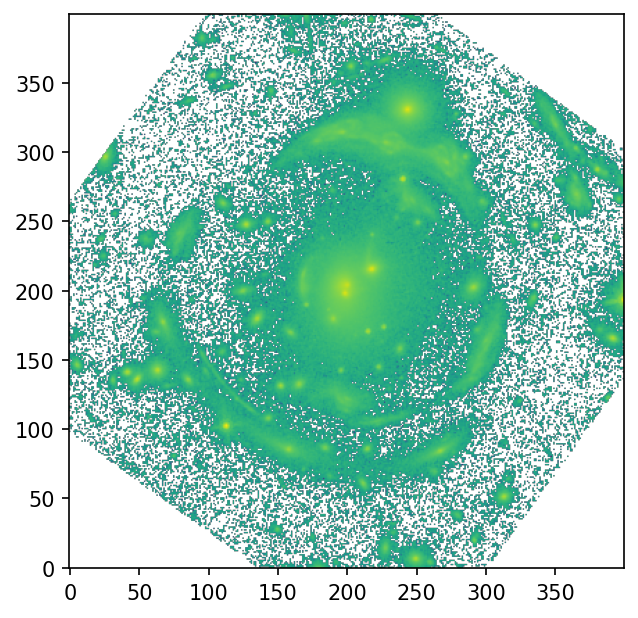

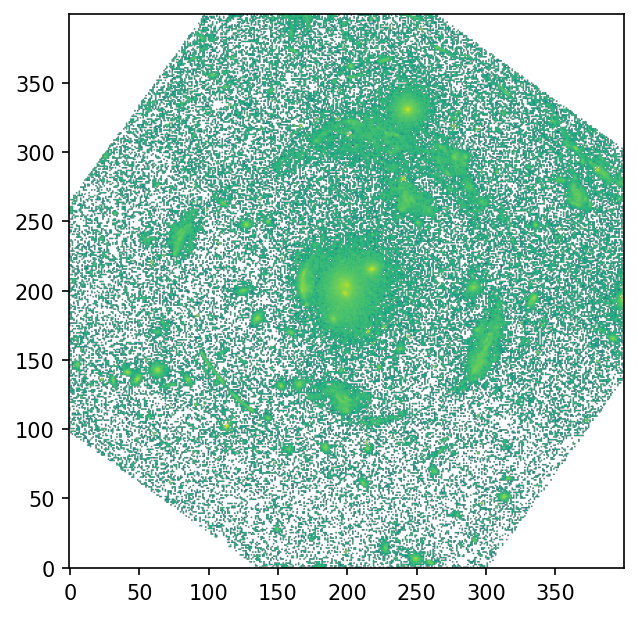

In [ ]:
import json

# All data produced by setup_data.ipynb — North-up, 2×2 binned, PSF loaded
obs    = np.load('data/obs.npy').astype(np.float32)   # F140W, N-up (official model input)
f200   = np.load('data/f200.npy').astype(np.float32)  # F200LP, N-up, aligned
rgb    = np.load('data/rgb.npy').astype(np.float32)   # RGB composite, N-up
kernel = np.load('data/kernel.npy')

# obs=f200

with open('data/meta.json') as f:
    meta = json.load(f)

delta_pix   = meta['delta_pix']
num_pix     = meta['num_pix']
exp_time    = meta['exp_time']
bkg_rms     = meta['bkg_rms']
north_angle = meta['north_angle']

extent = (-num_pix/2*delta_pix, num_pix/2*delta_pix,
          -num_pix/2*delta_pix, num_pix/2*delta_pix)
ext_n  = extent   # already North-up

print(f'obs    : {obs.shape}  δ={delta_pix:.5f}"/px  (N-up)')
print(f'exp_time={exp_time:.1f}s  bkg_rms={bkg_rms:.6f}')
print(f'North-up rotation applied in setup_data: {north_angle:.2f}°')
plt.imshow(obs, norm='log', origin='lower')
plt.show()
plt.imshow(f200, norm='log', origin='lower')
plt.show()

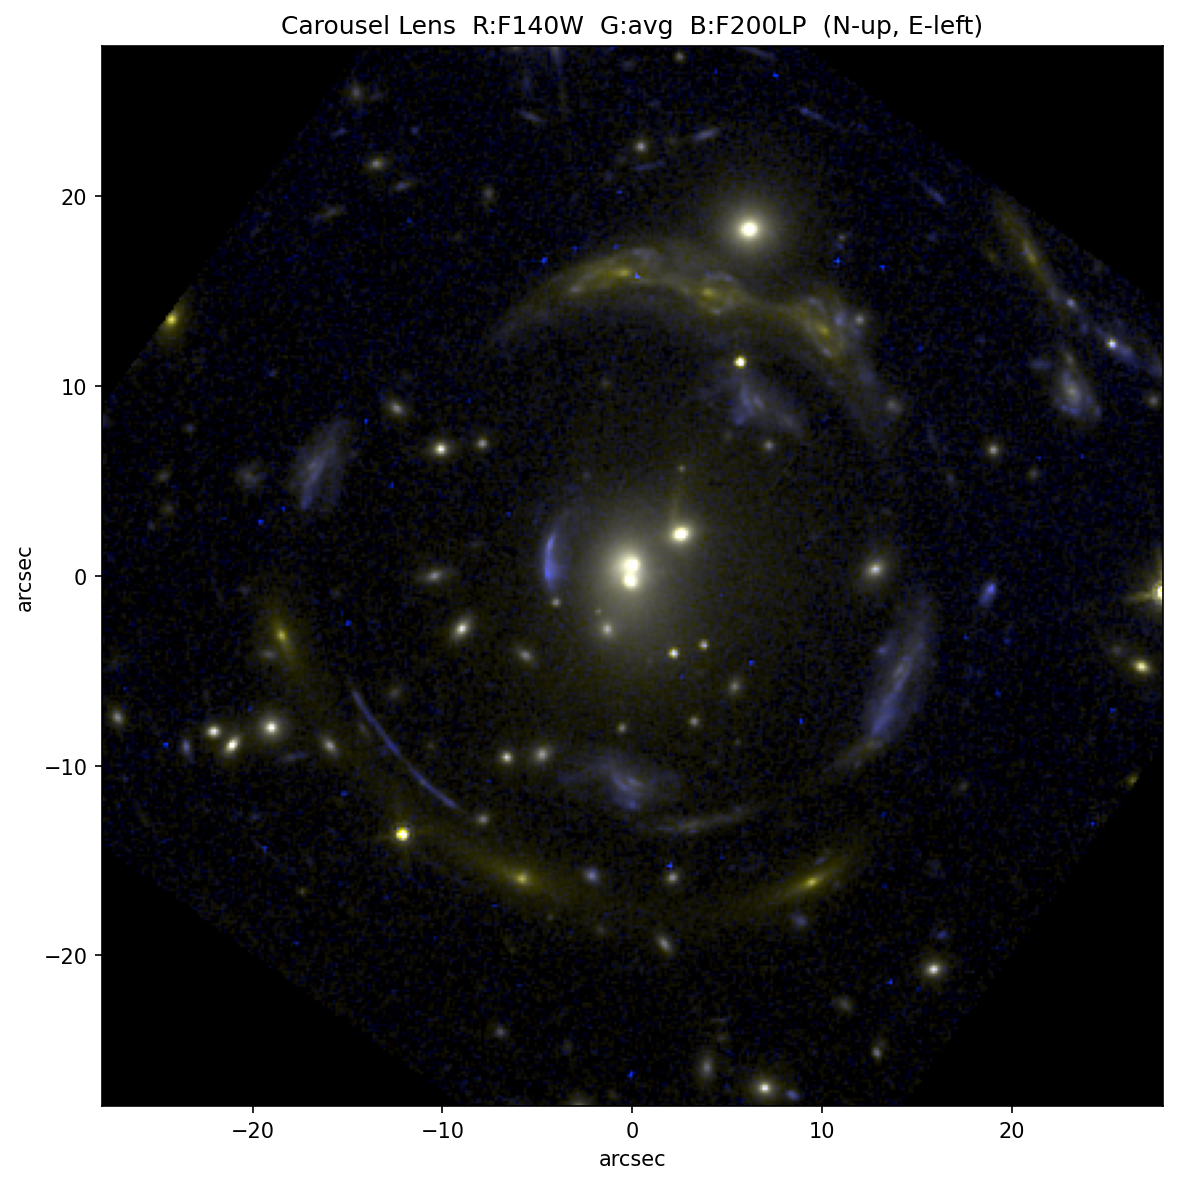

In [ ]:
from astropy.visualization import simple_norm

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb, origin='lower', extent=ext_n)
ax.set(xlabel='arcsec', ylabel='arcsec',
       title='Carousel Lens  R:F140W  G:avg  B:F200LP  (N-up, E-left)')
plt.tight_layout()
plt.show()

## 3. Priors

In [ ]:
# All positions and spin-2 quantities in North-up frame from setup_data.ipynb.
# Sheu+2024 does not tabulate source positions — S4 source prior centred on
# La (caustic centre); optimizer finds the true position during MAP.
DR4 = meta['dr_s4']

la_prior = Prior(mass.epl.EPL(), dict(
    center_x = tfd.Normal(0, 0.5),
    center_y = tfd.Normal(0, 0.5),
    e1       = tfd.TruncatedNormal(meta['la_e1'], 0.05, -0.3, 0.3),
    e2       = tfd.TruncatedNormal(meta['la_e2'], 0.05, -0.3, 0.3),
    theta_E  = tfd.Normal(meta['la_thetaE'], 0.5),
    gamma    = tfd.TruncatedNormal(meta['la_gamma'], 0.08, 1.5, 2.5),
))

ld_prior = Prior(mass.epl.EPL(), dict(
    center_x = tfd.Normal(meta['ld_cx'], 1.0),
    center_y = tfd.Normal(meta['ld_cy'], 1.0),
    e1       = tfd.TruncatedNormal(meta['ld_e1'], 0.05, -0.3, 0.3),
    e2       = tfd.TruncatedNormal(meta['ld_e2'], 0.05, -0.3, 0.3),
    theta_E  = tfd.Normal(meta['ld_thetaE'], 0.15),
    gamma    = tfd.TruncatedNormal(meta['ld_gamma'], 0.10, 1.5, 2.5),
))

shear_prior = Prior(mass.shear.Shear(), dict(
    gamma1 = tfd.Normal(meta['sh_g1'], 0.05),
    gamma2 = tfd.Normal(meta['sh_g2'], 0.05),
))

bcg_prior = Prior(light.sersic.SersicEllipse(use_lstsq=True), dict(
    center_x = tfd.Normal(0, 0.3),
    center_y = tfd.Normal(9, 0.3),
    e1       = tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
    e2       = tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
    n_sersic = tfd.Uniform(2., 8.),
    R_sersic = tfd.LogNormal(jnp.log(3.0), 0.3),
))

src4_prior = Prior(ss_mod.SersicShapelets(n_max=8, use_lstsq=True, cosmo_sample=False), dict(
    deflection_ratio = DR4,
    center_x  = tfd.Normal(0, 2.0),   # wide — optimizer finds true position
    center_y  = tfd.Normal(0, 2.0),
    e1        = tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
    e2        = tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
    n_sersic  = tfd.Uniform(0.5, 6.),
    R_sersic  = tfd.LogNormal(jnp.log(0.4), 0.3),
    beta      = tfd.LogNormal(jnp.log(0.4), 0.3),
))

prior, phys_model = make_prior_and_model(
    lenses=[la_prior, ld_prior, shear_prior], sources=[src4_prior], foreground=[bcg_prior],
)
print("Prior created — North-up, all from Sheu+2024 Table 2")
print(f"  La  ({meta['la_cx']:+.2f}\", {meta['la_cy']:+.2f}\")  "
      f"Ld ({meta['ld_cx']:+.2f}\", {meta['ld_cy']:+.2f}\")")

Prior created — North-up, all from Sheu+2024 Table 2
  La  (+7.81", -2.63")  Ld (+25.59", +3.88")


arc_mask: 12587 px


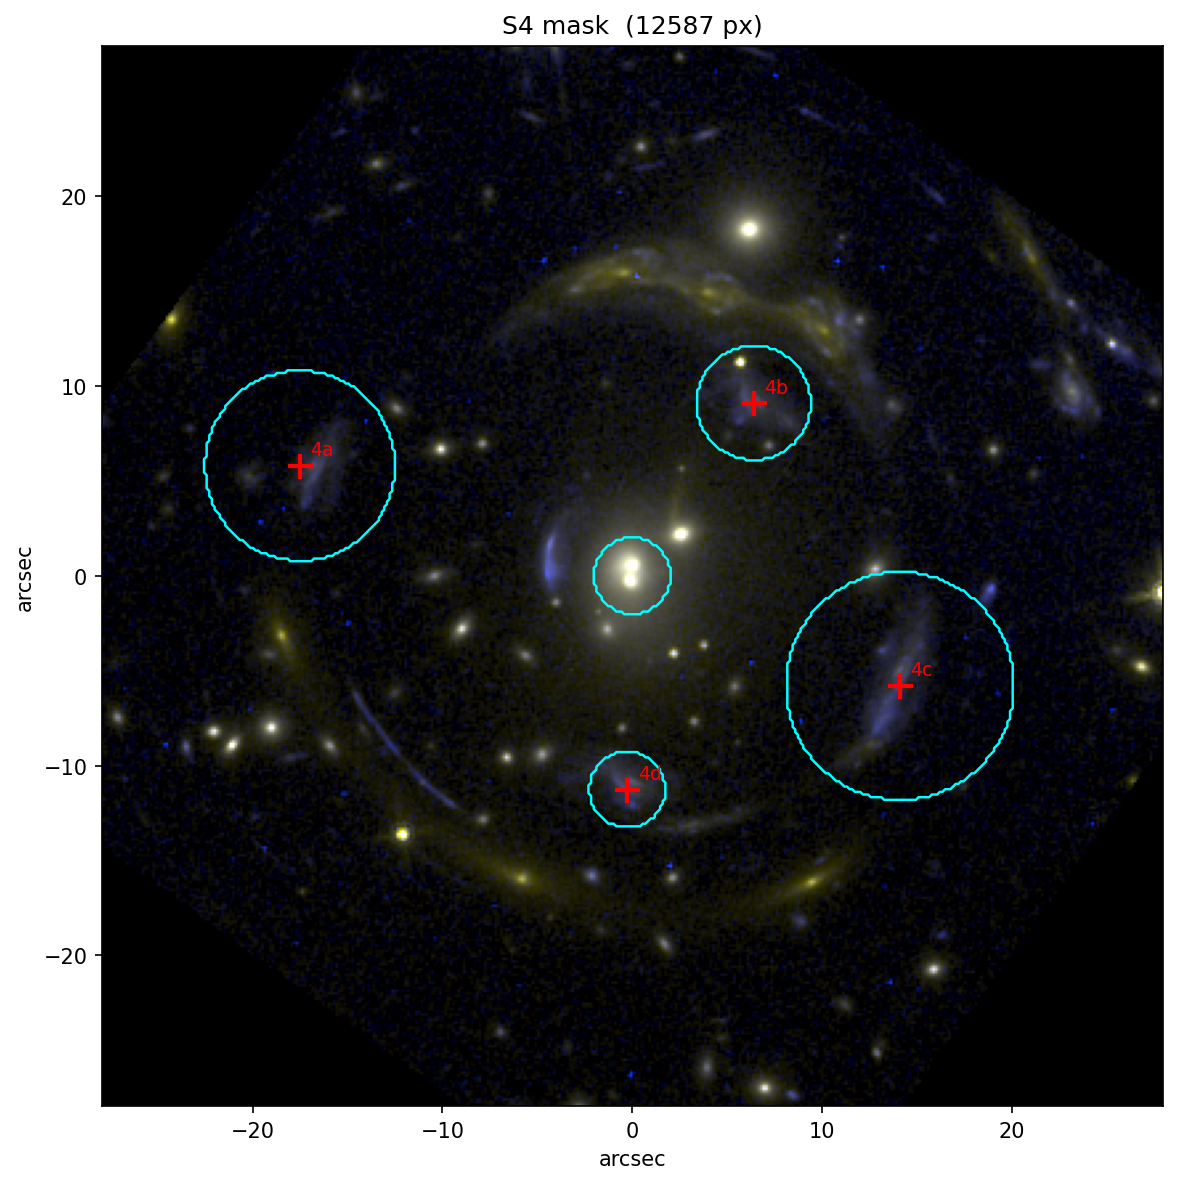

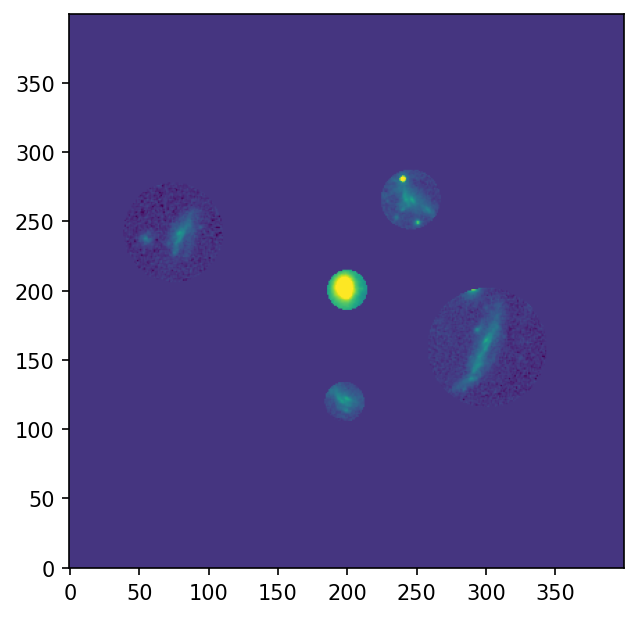

In [ ]:
# S4 arc image positions (arcsec, North-up) — measured visually from RGB
S4_ARCS = {
    '4a': (-17.50,   5.80, 5.0),
    '4b': (  6.40,   9.10, 3.0),
    '4c': ( 14.10,  -5.80, 6.0),
    '4d': ( -0.26, -11.26, 2.0),
}
R_BCG = 2.0   # arcsec radius on La/BCG

yy_, xx_ = np.mgrid[:num_pix, :num_pix]
xs_ = (xx_ - num_pix/2) * delta_pix
ys_ = (yy_ - num_pix/2) * delta_pix

arc_mask = np.zeros((num_pix, num_pix), dtype=bool)
for cx, cy, R_ARC in S4_ARCS.values():
    arc_mask |= np.sqrt((xs_ - cx)**2 + (ys_ - cy)**2) < R_ARC
arc_mask |= np.sqrt((xs_ - 0)**2 + (ys_ - 0)**2) < R_BCG

print(f'arc_mask: {int(arc_mask.sum())} px')

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb, origin='lower', extent=ext_n)
ax.contour(xs_, ys_, arc_mask.astype(float), levels=[0.5], colors='cyan', linewidths=1.2)
for label, (cx, cy, R_ARC) in S4_ARCS.items():
    ax.plot(cx, cy, 'r+', ms=12, mew=2)
    ax.annotate(label, (cx, cy), textcoords='offset points', xytext=(5, 5),
                color='red', fontsize=9)
ax.set(title=f'S4 mask  ({int(arc_mask.sum())} px)', xlabel='arcsec', ylabel='arcsec')
plt.tight_layout(); plt.show()
plt.figure()
plt.imshow(arc_mask*obs, norm=simple_norm(obs, 'sqrt', percent=99.5), origin='lower')
plt.show()

In [ ]:
sim_config = SimulatorConfig(delta_pix=delta_pix, num_pix=num_pix, supersample=1, kernel=kernel)

prob_model = BackwardProbModel(
    prior, obs, background_rms=bkg_rms, exp_time=exp_time, mask=arc_mask,
)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

## 6. MAP Optimization

In [ ]:
NUM_STEPS = 5000
N_SAMPLES = 16    # fewer chains — S4 mask is tight so convergence is faster

schedule  = optax.cosine_decay_schedule(init_value=3e-4, decay_steps=NUM_STEPS, alpha=1e-2)
optimizer = optax.adabelief(schedule, b1=0.95, b2=0.99)

start = prior.sample(N_SAMPLES, jax.random.PRNGKey(0))

print(f'Running MAP: {N_SAMPLES} chains x {NUM_STEPS} steps ...')
best, lps, chisq = model_seq.MAP(
    optimizer  = optimizer,
    n_samples  = N_SAMPLES,
    num_steps  = NUM_STEPS,
    start      = start,
    seed       = 0,
)
print(f'Done. Best reduced chi2 = {float(chisq[-1]):.4f}')

Running MAP: 20 chains x 5000 steps ...


  0%|          | 0/5000 [00:00<?, ?it/s]

## 7. Visualize

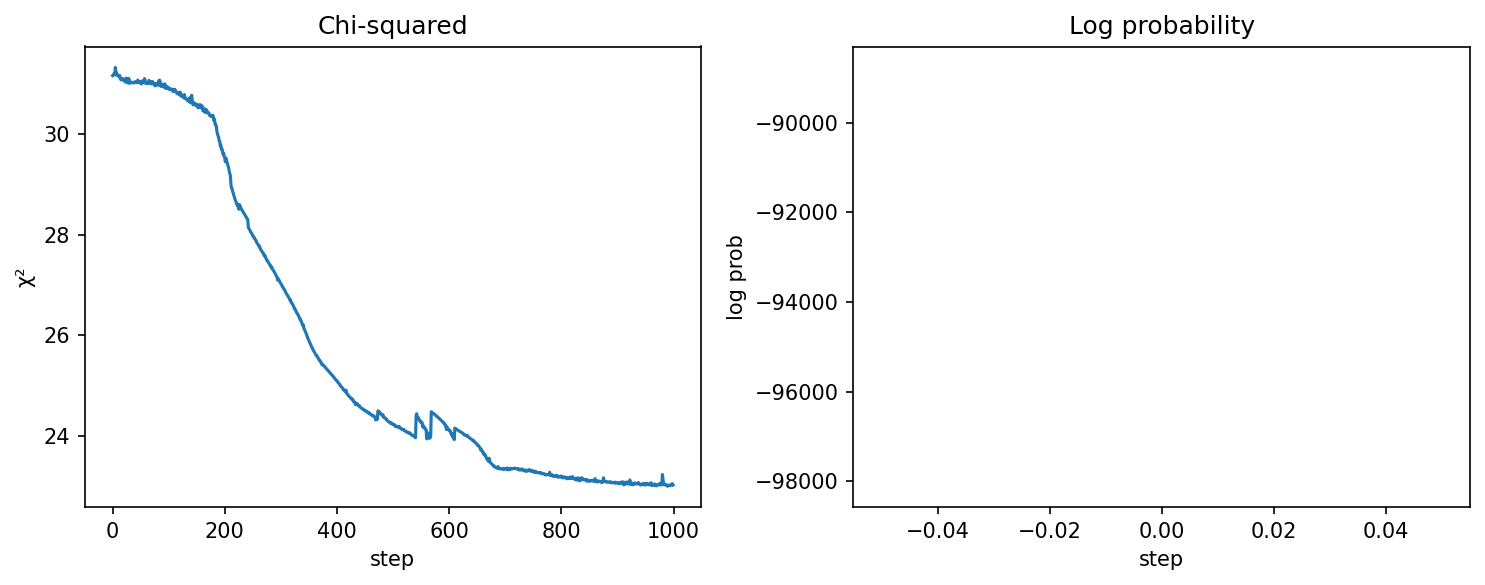

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(chisq); ax1.set(xlabel='step', ylabel='χ²', title='Chi-squared')
ax2.plot(lps);   ax2.set(xlabel='step', ylabel='log prob', title='Log probability')
plt.tight_layout(); plt.show()

2026-05-28 20:35:16.407560: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-05-28 20:35:20.478406: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng35{k2=1,k5=3,k14=2} for conv %cudnn-conv.1 = (f32[1,47,400,400]{3,2,1,0}, u8[0]{0}) custom-call(%select.109, %constant.39), window={size=27x27 pad=13_13x13_13}, dim_labels=bf01_oi01->bf01, feature_group_count=47, custom_call_target="__cudnn$convForward", metadata={op_name="jit(lstsq_simulate)/jit(main)/conv_general_dilated" source_file="/global/u1/c/chaseg/carousel-gigalens/../sean-carousel/src/gigalens/jax/simulator.py" source_line=265}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"

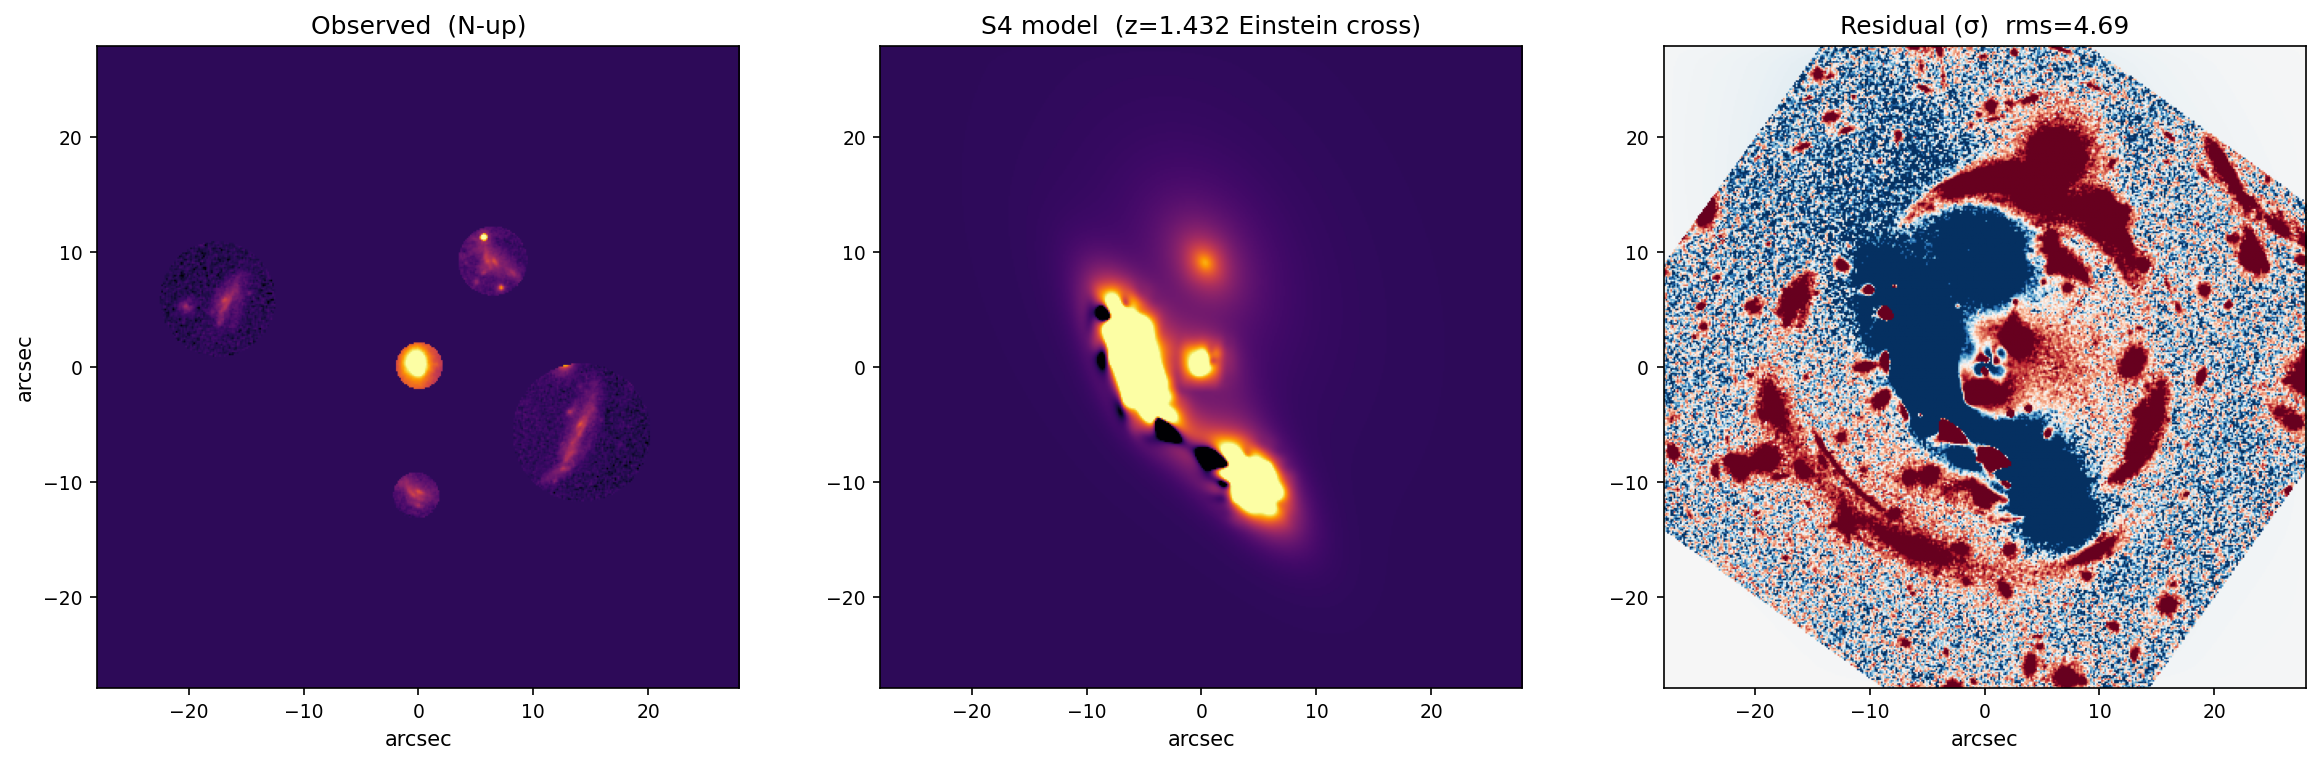

In [ ]:
simulator   = LensSimulator(phys_model, sim_config, bs=1)
best_params = prob_model.bij.forward(list(best.T))
err_map     = np.array(prob_model.error_map)
sim_im      = np.array(prob_model.simulate(simulator, best_params))
residual    = (obs - sim_im) / err_map

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
n = simple_norm(obs, 'sqrt', percent=99.5)

axes[0].imshow(obs*arc_mask,      norm=n, origin='lower', cmap='inferno', extent=ext_n)
axes[0].set(title='Observed  (N-up)', xlabel='arcsec', ylabel='arcsec')

axes[1].imshow(sim_im,   norm=n, origin='lower', cmap='inferno', extent=ext_n)
axes[1].set(title='S4 model  (z=1.432 Einstein cross)', xlabel='arcsec')

axes[2].imshow(residual, origin='lower', cmap='RdBu_r', vmin=-5, vmax=5, extent=ext_n)
axes[2].set(title=f'Residual (σ)  rms={np.nanstd(residual[arc_mask]):.2f}', xlabel='arcsec')

for ax in axes:
    ax.tick_params(labelsize=9)
plt.tight_layout()
import os; os.makedirs('models', exist_ok=True)
plt.savefig('models/src4_MAP.png', dpi=150)
plt.show()

## 9. Caustics & Critical Curves

In [ ]:
"""
Critical curves (image plane) and caustics (source plane).
Data is already North-up — no rotation needed for display.
"""

best_params_phys = prob_model.bij.forward(list(best.T))
lens_params      = best_params_phys['lens_mass']
src_params       = {k: v for k, v in best_params_phys['source_light']['0'].items()
                    if k != 'deflection_ratio'}

N_CC = 500
half = num_pix / 2 * delta_pix
xs   = np.linspace(-half, half, N_CC)
X, Y = np.meshgrid(xs, xs)
Xj, Yj = jnp.array(X.ravel()), jnp.array(Y.ravel())

@jax.jit
def total_alpha(x, y):
    ax, ay = jnp.zeros_like(x), jnp.zeros_like(y)
    for i, lp in enumerate(phys_model.lenses):
        dax, day = lp.deriv(x, y, **lens_params[str(i)])
        ax, ay = ax + dax, ay + day
    return ax, ay

ax0, ay0 = total_alpha(Xj, Yj)
eps = delta_pix * 0.5
ax_xp, ay_xp = total_alpha(Xj+eps, Yj);  ax_xm, ay_xm = total_alpha(Xj-eps, Yj)
ax_yp, ay_yp = total_alpha(Xj, Yj+eps);  ax_ym, ay_ym = total_alpha(Xj, Yj-eps)

dax_dx = np.array((ax_xp-ax_xm)/(2*eps)).reshape(N_CC, N_CC)
dax_dy = np.array((ax_yp-ax_ym)/(2*eps)).reshape(N_CC, N_CC)
day_dx = np.array((ay_xp-ay_xm)/(2*eps)).reshape(N_CC, N_CC)
day_dy = np.array((ay_yp-ay_ym)/(2*eps)).reshape(N_CC, N_CC)

det_A = (1-DR4*dax_dx)*(1-DR4*day_dy) - (DR4*dax_dy)*(DR4*day_dx)
bx = X - DR4*np.array(ax0).reshape(N_CC, N_CC)
by = Y - DR4*np.array(ay0).reshape(N_CC, N_CC)

# Source brightness from lstsq coefficients
simulator_cc = LensSimulator(phys_model, sim_config, bs=1)
coeffs = np.array(simulator_cc.lstsq_simulate(
    best_params_phys, jnp.array(obs),
    jnp.array(np.array(prob_model.error_map)),
    jnp.array(arc_mask), return_coeffs=True,
))
s4_coeffs   = coeffs[phys_model.lens_light[0].depth:]
src_profile = phys_model.source_light[0]
SRC_HALF = 10.0;  ns = 400
xs_s = np.linspace(-SRC_HALF, SRC_HALF, ns)
Xs, Ys = np.meshgrid(xs_s, xs_s)
basis = np.array(src_profile.light(jnp.array(Xs.ravel()), jnp.array(Ys.ravel()), **src_params))
src_brightness = (s4_coeffs[:, None] * basis).sum(axis=0).reshape(ns, ns)
src_extent = (-SRC_HALF, SRC_HALF, -SRC_HALF, SRC_HALF)
cx_src = float(np.array(src_params['center_x']).ravel()[0])
cy_src = float(np.array(src_params['center_y']).ravel()[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

norm_im = simple_norm(sim_im, 'sqrt', percent=99.5)
axes[0].imshow(sim_im, norm=norm_im, origin='lower', cmap='inferno', extent=ext_n)
axes[0].contour(X, Y, det_A, levels=[0], colors='red', linewidths=0.9)
axes[0].set(title='Model + critical curves  (N-up)', xlabel='arcsec', ylabel='arcsec')

norm_src = simple_norm(np.clip(src_brightness, 0, None), 'sqrt', percent=99.5)
axes[1].imshow(src_brightness, norm=norm_src, origin='lower', cmap='inferno', extent=src_extent)
axes[1].contour(bx, by, det_A, levels=[0], colors='lime', linewidths=0.9)
axes[1].plot(cx_src, cy_src, '+', color='white', ms=10, mew=1.5)
axes[1].set(title='Source plane + caustic  (S4, z=1.432)',
            xlabel='arcsec', ylabel='arcsec', xlim=src_extent[:2], ylim=src_extent[2:])

plt.tight_layout()
plt.savefig('models/src4_caustics.png', dpi=150)
plt.show()

ValueError: operands could not be broadcast together with shapes (0,1,47) (46,160000) 

## 8. Save

In [ ]:
import os
os.makedirs('models', exist_ok=True)
np.save('models/src4_best.npy',  np.array(best))
np.save('models/src4_chisq.npy', np.array(chisq))
np.save('models/src4_lps.npy',   np.array(lps))

best_phys = prob_model.bij.forward(list(best.T))
print('Best-fit parameters:')
for section, vals in best_phys.items():
    for comp, params in vals.items():
        print(f'  [{section}/{comp}]')
        if isinstance(params, dict):
            for k, v in params.items():
                try:
                    print(f'    {k}: {float(np.array(v).ravel()[0]):.5f}')
                except Exception:
                    print(f'    {k}: {v}')
print('Saved → models/src4_*.npy')